In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

In [8]:
DATA = Path("../processed_data/")

print(DATA)

../processed_data


In [9]:
from pathlib import Path

DATA = Path("../processed_data")

print(DATA.resolve())
print(DATA.exists())

/Users/priyanshukumar/Desktop/FYP/processed_data
True


In [10]:
print(DATA.resolve())
print(DATA.exists())

/Users/priyanshukumar/Desktop/FYP/processed_data
True


In [11]:
X = np.load(DATA / "X_filtered.npy", mmap_mode="r")
y = np.load(DATA / "y.npy")

metadata = pd.read_csv(DATA / "metadata.csv")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("metadata shape:", metadata.shape)

X shape: (7104, 512, 14)
y shape: (7104,)
metadata shape: (7104, 5)


In [12]:
window = X[0]

print("Window shape:", window.shape)

Window shape: (512, 14)


In [13]:
print(window[:5])

[[-6.9342059e-01 -2.4226489e+00  3.6277919e+00  8.4614916e+00
   1.6252622e-01 -3.7884016e+00 -5.0062714e+00 -1.4859582e+00
   1.3265929e+00  1.1367413e-02  2.3625469e+00 -3.1797574e+00
   3.0500345e+00  2.6086457e+00]
 [-4.7787595e+00 -1.3037890e+01  6.9099097e+00 -1.3850279e+01
  -4.7639756e+00 -2.0100415e+00 -3.4348959e-01  2.9812005e+00
   5.5985250e+00  8.2613316e+00  5.8481669e+00 -1.2744612e+01
   2.5449032e+01 -3.7948147e+01]
 [-1.4195536e+01 -1.4693039e+01  7.3710203e+00  5.8696769e-02
  -4.0847135e+00 -1.1662608e+00  4.8591571e+00  8.7458944e+00
   1.1434841e+01  1.9078220e+01  4.9036775e+00 -1.9286455e+01
   3.7823223e+01 -4.6343716e+01]
 [-1.6251644e+01 -7.7856822e+00  4.8297124e+00  3.6950722e+01
   5.9419613e+00  3.2787573e-01  6.7832346e+00  1.4277015e+01
   1.4954486e+01  2.2925312e+01  1.0717496e+01 -1.3593727e+01
   3.8094784e+01 -2.3406914e+01]
 [-1.2462417e+01 -5.0498610e+00  2.9695767e-01  4.8547089e+01
   1.4148893e+01  2.9609897e+00  4.6546383e+00  1.3366864e+01


In [14]:
CHANNELS = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

print(len(CHANNELS))

14


In [15]:
FS = 128

time = np.arange(window.shape[0]) / FS

print("Start:", time[0], "seconds")
print("End:", time[-1], "seconds")

Start: 0.0 seconds
End: 3.9921875 seconds


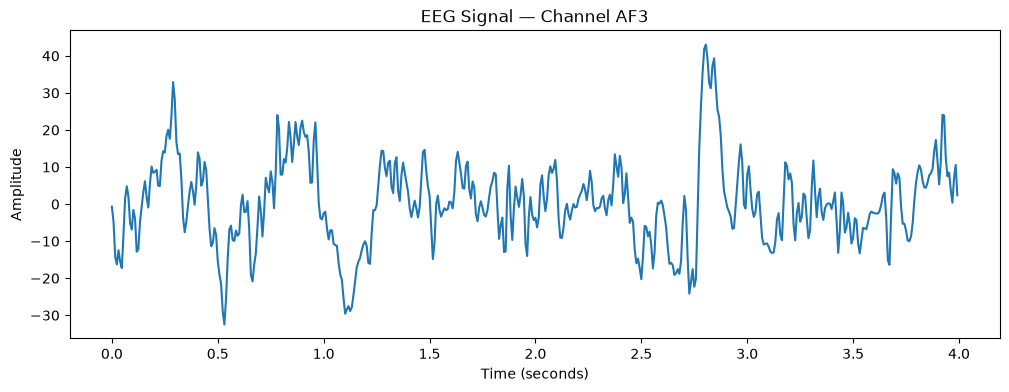

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(time, window[:, 0])

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("EEG Signal — Channel AF3")

plt.show()

In [17]:
print("Window index:", 0)
print("Label:", y[0])
print("Subject:", metadata.iloc[0]["subject"])

Window index: 0
Label: 1
Subject: 1


In [19]:
from scipy.signal import welch

FS = 128

frequencies, psd = welch(
    window,
    fs=FS,
    window="hann",
    nperseg=256,
    noverlap=128,
    detrend="constant",
    axis=0
)

print("Frequency shape:", frequencies.shape)
print("PSD shape:", psd.shape)

Frequency shape: (129,)
PSD shape: (129, 14)


In [20]:
print(frequencies[:15])

[0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7. ]


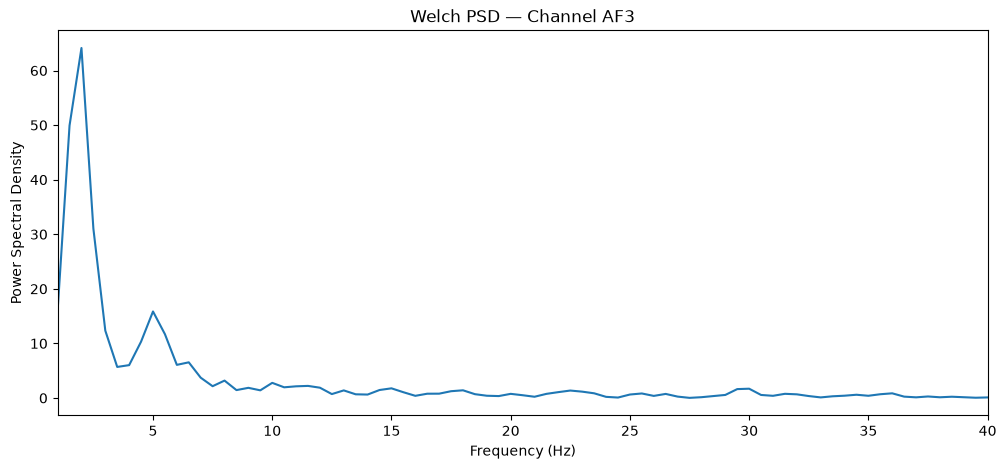

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    frequencies,
    psd[:, 0]
)

plt.xlim(1, 40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Welch PSD — Channel AF3")

plt.show()

In [22]:
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "low_gamma": (30, 40)
}

print(BANDS)

{'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30), 'low_gamma': (30, 40)}


In [23]:
channel_idx = 0

channel_psd = psd[:, channel_idx]

print("AF3 PSD shape:", channel_psd.shape)

AF3 PSD shape: (129,)


In [24]:
low = 8
high = 13

mask = (frequencies >= low) & (frequencies < high)

alpha_power = np.trapezoid(
    channel_psd[mask],
    frequencies[mask]
)

print("AF3 Alpha Power:", alpha_power)

AF3 Alpha Power: 8.821341454982758


In [25]:
af3_features = {}

for band_name, (low, high) in BANDS.items():

    mask = (frequencies >= low) & (frequencies < high)

    power = np.trapezoid(
        channel_psd[mask],
        frequencies[mask]
    )

    af3_features[band_name] = power

print(af3_features)

{'delta': np.float64(84.12848854064941), 'theta': np.float64(29.150063514709473), 'alpha': np.float64(8.821341454982758), 'beta': np.float64(12.082496214658022), 'low_gamma': np.float64(4.087915286421776)}


In [26]:
def extract_absolute_band_power(window):

    frequencies, psd = welch(
        window,
        fs=128,
        window="hann",
        nperseg=256,
        noverlap=128,
        detrend="constant",
        axis=0
    )

    features = []

    for channel_idx in range(len(CHANNELS)):

        channel_psd = psd[:, channel_idx]

        for band_name, (low, high) in BANDS.items():

            mask = (frequencies >= low) & (frequencies < high)

            power = np.trapezoid(
                channel_psd[mask],
                frequencies[mask]
            )

            features.append(power)

    return np.array(features)

In [27]:
features = extract_absolute_band_power(window)

print("Feature shape:", features.shape)
print(features)

Feature shape: (70,)
[ 84.12848854  29.15006351   8.82134145  12.08249621   4.08791529
 208.14683723  63.70541668  23.27528     18.73071687   6.36433527
  49.82096839  16.7008183    4.75543118   7.9836394    4.1039681
 119.10201931  11.8312372    6.68081653  10.189507     7.02804928
  19.70069599   5.80353981   2.17700547   4.63806814   2.43314144
  46.40894222   5.58573705   4.0543955    8.0151234    3.94582291
  84.54621935  17.68304634   5.48490143  12.09040906   4.29903133
  52.82698107  17.43531096   7.64980555  12.67469344   4.65535876
  46.94786549  22.32312071   6.63971317  12.9885302    5.44283413
  70.25010777  25.81268132   6.76401985  11.266356     5.29150763
 173.07929039  55.35106039   8.21219781  14.09212355   3.69828982
 633.14017105  48.22352898   5.23929098  12.88526763   3.37275092
 317.39870453  84.39798641  17.53487432  16.85631137   4.87207258
 253.75028992  66.56141901  16.02420139  21.79402225   6.26906247]


In [28]:
feature_names = []

for channel in CHANNELS:
    for band in BANDS:
        feature_names.append(f"{channel}_{band}")

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 70
['AF3_delta', 'AF3_theta', 'AF3_alpha', 'AF3_beta', 'AF3_low_gamma', 'F7_delta', 'F7_theta', 'F7_alpha', 'F7_beta', 'F7_low_gamma', 'F3_delta', 'F3_theta', 'F3_alpha', 'F3_beta', 'F3_low_gamma', 'FC5_delta', 'FC5_theta', 'FC5_alpha', 'FC5_beta', 'FC5_low_gamma', 'T7_delta', 'T7_theta', 'T7_alpha', 'T7_beta', 'T7_low_gamma', 'P7_delta', 'P7_theta', 'P7_alpha', 'P7_beta', 'P7_low_gamma', 'O1_delta', 'O1_theta', 'O1_alpha', 'O1_beta', 'O1_low_gamma', 'O2_delta', 'O2_theta', 'O2_alpha', 'O2_beta', 'O2_low_gamma', 'P8_delta', 'P8_theta', 'P8_alpha', 'P8_beta', 'P8_low_gamma', 'T8_delta', 'T8_theta', 'T8_alpha', 'T8_beta', 'T8_low_gamma', 'FC6_delta', 'FC6_theta', 'FC6_alpha', 'FC6_beta', 'FC6_low_gamma', 'F4_delta', 'F4_theta', 'F4_alpha', 'F4_beta', 'F4_low_gamma', 'F8_delta', 'F8_theta', 'F8_alpha', 'F8_beta', 'F8_low_gamma', 'AF4_delta', 'AF4_theta', 'AF4_alpha', 'AF4_beta', 'AF4_low_gamma']


In [29]:
def extract_absolute_band_power(window):
    frequencies, psd = welch(
        window,
        fs=128,
        window="hann",
        nperseg=256,
        noverlap=128,
        detrend="constant",
        axis=0
    )

    features = []

    for channel_idx in range(len(CHANNELS)):

        channel_psd = psd[:, channel_idx]

        for band_name, (low, high) in BANDS.items():

            mask = (frequencies >= low) & (frequencies < high)

            power = np.trapezoid(
                channel_psd[mask],
                frequencies[mask]
            )

            features.append(power)

    return np.array(features)

In [30]:
n_windows = X.shape[0]

all_features = []

for i in range(n_windows):

    window_features = extract_absolute_band_power(X[i])

    all_features.append(window_features)

X_abs = np.array(all_features) # absolute power band 

print("Feature matrix shape:", X_abs.shape)

Feature matrix shape: (7104, 70)


In [31]:
X_abs_df = pd.DataFrame(
    X_abs,
    columns=feature_names
)

print(X_abs_df.shape)
X_abs_df.head()

(7104, 70)


,AF3_delta,AF3_theta,AF3_alpha,AF3_beta,AF3_low_gamma,F7_delta,F7_theta,F7_alpha,F7_beta,F7_low_gamma,...,F8_delta,F8_theta,F8_alpha,F8_beta,F8_low_gamma,AF4_delta,AF4_theta,AF4_alpha,AF4_beta,AF4_low_gamma
0,84.128489,29.150064,8.821341,12.082496,4.087915,208.146837,63.705417,23.275280,18.730717,6.364335,...,317.398705,84.397986,17.534874,16.856311,4.872073,253.750290,66.561419,16.024201,21.794022,6.269062
1,115.035023,87.724389,21.156880,15.516373,5.443226,1036.320808,109.492164,24.680465,29.974753,7.884612,...,372.812801,118.794613,26.478896,19.964370,8.143499,292.353832,118.991697,26.384185,23.525102,10.266504
2,485.603516,201.108252,32.781150,25.417641,12.626147,1561.916237,157.960798,27.355302,44.511068,13.133650,...,548.994072,168.754866,27.987143,31.694372,22.214061,755.972221,290.533712,59.475293,47.741277,23.303699
3,357.255642,111.033887,27.088925,25.385745,8.707622,737.825996,133.861629,27.290368,31.596493,12.570034,...,856.311462,100.145923,21.261084,30.588360,11.959464,777.791420,168.645493,44.676300,40.481663,14.370122
4,208.576025,36.671074,13.782472,44.769161,10.741919,1172.191101,129.107060,45.631694,61.494881,17.202737,...,624.035645,64.395215,25.976917,50.073751,18.190898,398.616726,54.826693,22.111106,57.815289,22.317758


In [38]:
feature_table = X_abs_df.copy()

feature_table["label"] = y
feature_table["subject"] = metadata["subject"].values
feature_table["condition"] = metadata["condition"].values

print(feature_table.shape)

(7104, 73)


In [39]:
print("Subjects:", feature_table["subject"].nunique())

print("\nLabels:")
print(feature_table["label"].value_counts())

print("\nWindows per subject/label:")
print(
    feature_table
    .groupby(["subject", "label"])
    .size()
    .head(10)
)

Subjects: 48

Labels:
label
1    3552
0    3552
Name: count, dtype: int64

Windows per subject/label:
subject  label
1        0        74
         1        74
2        0        74
         1        74
3        0        74
         1        74
4        0        74
         1        74
5        0        74
         1        74
dtype: int64


In [40]:
channel_idx = 0
channel_psd = psd[:, channel_idx]

total_mask = (frequencies >= 1) & (frequencies < 40)

total_power = np.trapezoid(
    channel_psd[total_mask],
    frequencies[total_mask]
)

print("AF3 total power:", total_power)

AF3 total power: 143.89596501365304


In [41]:
alpha_mask = (frequencies >= 8) & (frequencies < 13)

alpha_power = np.trapezoid(
    channel_psd[alpha_mask],
    frequencies[alpha_mask]
)

relative_alpha = alpha_power / total_power

print("Absolute alpha power:", alpha_power)
print("Relative alpha power:", relative_alpha)

Absolute alpha power: 8.821341454982758
Relative alpha power: 0.06130360538007982


In [42]:
def extract_relative_band_power(window):

    frequencies, psd = welch(
        window,
        fs=128,
        window="hann",
        nperseg=256,
        noverlap=128,
        detrend="constant",
        axis=0
    )

    features = []

    for channel_idx in range(len(CHANNELS)):

        channel_psd = psd[:, channel_idx]

        # Total power from 1–40 Hz
        total_mask = (frequencies >= 1) & (frequencies < 40)

        total_power = np.trapezoid(
            channel_psd[total_mask],
            frequencies[total_mask]
        )

        for band_name, (low, high) in BANDS.items():

            mask = (frequencies >= low) & (frequencies < high)

            band_power = np.trapezoid(
                channel_psd[mask],
                frequencies[mask]
            )

            relative_power = band_power / total_power

            features.append(relative_power)

    return np.array(features)

In [43]:
relative_features = extract_relative_band_power(window)

print("Relative feature shape:", relative_features.shape)
print(relative_features)

Relative feature shape: (70,)
[0.584648   0.20257735 0.06130361 0.08396689 0.02840882 0.60169291
 0.18415412 0.06728217 0.05414514 0.01839747 0.57118964 0.19147228
 0.05452028 0.09153118 0.04705135 0.74701965 0.07420669 0.04190274
 0.0639096  0.04408062 0.53314936 0.15705808 0.05891513 0.12551755
 0.0658468  0.65547498 0.07889236 0.05726385 0.11320475 0.05573038
 0.65385492 0.13675534 0.04241857 0.09350357 0.03324741 0.53334556
 0.17602834 0.07723307 0.12796475 0.04700089 0.47515585 0.22593064
 0.06720004 0.13145595 0.05508652 0.56254121 0.2067     0.05416419
 0.09021751 0.04237276 0.63934566 0.20446386 0.03033542 0.05205555
 0.01366129 0.87411129 0.06657725 0.00723335 0.01778936 0.00465641
 0.67518085 0.17953414 0.03730076 0.03585729 0.01036403 0.65921241
 0.17291848 0.04162893 0.05661822 0.01628626]


In [44]:
af3_relative = relative_features[:5]

print("AF3 relative powers:")
print(af3_relative)

print("Sum:", af3_relative.sum())

AF3 relative powers:
[0.584648   0.20257735 0.06130361 0.08396689 0.02840882]
Sum: 0.960904671637611


In [45]:
all_relative_features = []

for i in range(X.shape[0]):

    window_features = extract_relative_band_power(X[i])

    all_relative_features.append(window_features)

X_rel = np.array(all_relative_features)

print("Relative feature matrix shape:", X_rel.shape)

Relative feature matrix shape: (7104, 70)


In [46]:
X_rel_df = pd.DataFrame(
    X_rel,
    columns=feature_names
)

print(X_rel_df.shape)
X_rel_df.head()

(7104, 70)


,AF3_delta,AF3_theta,AF3_alpha,AF3_beta,AF3_low_gamma,F7_delta,F7_theta,F7_alpha,F7_beta,F7_low_gamma,...,F8_delta,F8_theta,F8_alpha,F8_beta,F8_low_gamma,AF4_delta,AF4_theta,AF4_alpha,AF4_beta,AF4_low_gamma
0,0.584648,0.202577,0.061304,0.083967,0.028409,0.601693,0.184154,0.067282,0.054145,0.018397,...,0.675181,0.179534,0.037301,0.035857,0.010364,0.659212,0.172918,0.041629,0.056618,0.016286
1,0.434487,0.331335,0.079909,0.058605,0.020559,0.834417,0.088160,0.019872,0.024135,0.006348,...,0.649379,0.206921,0.046122,0.034775,0.014185,0.574919,0.233999,0.051885,0.046263,0.020189
2,0.579280,0.239904,0.039105,0.030321,0.015062,0.842838,0.085239,0.014761,0.024019,0.007087,...,0.616161,0.189401,0.031411,0.035572,0.024932,0.572585,0.220055,0.045048,0.036160,0.017651
3,0.645155,0.200512,0.048919,0.045843,0.015725,0.735053,0.133359,0.027188,0.031478,0.012523,...,0.801368,0.093720,0.019897,0.028626,0.011192,0.708410,0.153602,0.040691,0.036871,0.013088
4,0.634079,0.111481,0.041899,0.136100,0.032656,0.779068,0.085808,0.030328,0.040871,0.011433,...,0.735524,0.075900,0.030618,0.059020,0.021441,0.669802,0.092126,0.037154,0.097148,0.037501


In [47]:
comparison = pd.DataFrame({
    "feature": feature_names,
    "absolute_power": X_abs[0],
    "relative_power": X_rel[0]
})

comparison.head(10)

,feature,absolute_power,relative_power
0,AF3_delta,84.128489,0.584648
1,AF3_theta,29.150064,0.202577
2,AF3_alpha,8.821341,0.061304
3,AF3_beta,12.082496,0.083967
4,AF3_low_gamma,4.087915,0.028409
5,F7_delta,208.146837,0.601693
6,F7_theta,63.705417,0.184154
7,F7_alpha,23.275280,0.067282
8,F7_beta,18.730717,0.054145
9,F7_low_gamma,6.364335,0.018397


ML PART STARTING ....
This is the point where we need to be very careful about data leakage. A model can appear excellent if we split EEG windows incorrectly, so we're going to set up the evaluation properly before training anything.
Create the Subject-Wise ML Split
X_abs → (7104, 70)
X_rel → (7104, 70)
y     → (7104,)
48 subjects
        │
        ├─────────────── Development ───────────────┐
        │                                           │
        │   38 subjects                             │
        │       ↓                                   │
        │   5-fold subject-wise CV                 │
        │                                           │
        └── Test: 10 subjects ─────────────────────┘
        

In [55]:
import json

with open(DATA / "splits.json", "r") as f:
    splits = json.load(f)

print(splits.keys())

dict_keys(['meta', 'train_subjects', 'validation_subjects', 'test_subjects', 'development_subjects', 'cv'])


In [56]:
print(json.dumps(splits, indent=2)[:5000])

{
  "meta": {
    "unit_of_split": "subject (all windows of a subject stay together)",
    "seed_train_val_split": 42,
    "seed_cv_folds": 43,
    "n_subjects": 48,
    "test_subjects_origin": "frozen from original notebook split (random_state=42, test_size=0.2)",
    "normalization": "none - must be fitted on training subjects only"
  },
  "train_subjects": [
    1,
    2,
    3,
    4,
    7,
    9,
    10,
    11,
    12,
    14,
    15,
    17,
    18,
    19,
    21,
    22,
    23,
    24,
    29,
    30,
    31,
    32,
    33,
    36,
    37,
    40,
    42,
    45,
    46,
    48
  ],
  "validation_subjects": [
    6,
    8,
    16,
    34,
    35,
    39,
    43,
    47
  ],
  "test_subjects": [
    5,
    13,
    20,
    25,
    26,
    27,
    28,
    38,
    41,
    44
  ],
  "development_subjects": [
    1,
    2,
    3,
    4,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    14,
    15,
    16,
    17,
    18,
    19,
    21,
    22,
    23,
    24,
    29,
    3

In [50]:
print(metadata[["subject", "condition", "label", "window"]].head())

   subject condition  label  window
0        1      high      1       0
1        1      high      1       1
2        1      high      1       2
3        1      high      1       3
4        1      high      1       4


In [51]:
print(metadata["subject"].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]


In [52]:
print("Number of subjects:", metadata["subject"].nunique())

Number of subjects: 48


In [53]:
print(metadata["subject"].head(10).tolist())
print(type(metadata["subject"].iloc[0]))

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
<class 'numpy.int64'>


In [57]:
train_subjects = splits["train_subjects"]

In [58]:
print(metadata["subject"].head(10).tolist())
print(type(metadata["subject"].iloc[0]))
print("Number of subjects:", metadata["subject"].nunique())

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
<class 'numpy.int64'>
Number of subjects: 48


Step 7A — Load the frozen subjects

In [59]:
import json

with open(DATA / "splits.json", "r") as f:
    splits = json.load(f)

train_subjects = splits["train_subjects"]
validation_subjects = splits["validation_subjects"]
test_subjects = splits["test_subjects"]
development_subjects = splits["development_subjects"]

print("Train subjects:", train_subjects)
print("Validation subjects:", validation_subjects)
print("Test subjects:", test_subjects)

print("\nCounts:")
print("Train:", len(train_subjects))
print("Validation:", len(validation_subjects))
print("Development:", len(development_subjects))
print("Test:", len(test_subjects))

Train subjects: [1, 2, 3, 4, 7, 9, 10, 11, 12, 14, 15, 17, 18, 19, 21, 22, 23, 24, 29, 30, 31, 32, 33, 36, 37, 40, 42, 45, 46, 48]
Validation subjects: [6, 8, 16, 34, 35, 39, 43, 47]
Test subjects: [5, 13, 20, 25, 26, 27, 28, 38, 41, 44]

Counts:
Train: 30
Validation: 8
Development: 38
Test: 10


In [60]:
def rows_of(subjects):
    return np.flatnonzero(
        metadata["subject"].isin(subjects).to_numpy()
    )

In [61]:
train_idx = rows_of(train_subjects)
val_idx = rows_of(validation_subjects)
test_idx = rows_of(test_subjects)

print("Train windows:", len(train_idx))
print("Validation windows:", len(val_idx))
print("Test windows:", len(test_idx))

Train windows: 4440
Validation windows: 1184
Test windows: 1480


In [62]:
X_train = X_abs[train_idx]
y_train = y[train_idx]

X_val = X_abs[val_idx]
y_val = y[val_idx]

X_test = X_abs[test_idx]
y_test = y[test_idx]

In [63]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4440, 70)
y_train: (4440,)
X_val: (1184, 70)
y_val: (1184,)
X_test: (1480, 70)
y_test: (1480,)


In [64]:
train_set = set(train_subjects)
val_set = set(validation_subjects)
test_set = set(test_subjects)

print("Train ∩ Validation:", train_set & val_set)
print("Train ∩ Test:", train_set & test_set)
print("Validation ∩ Test:", val_set & test_set)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


In [65]:
print("Training labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation labels:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest labels:")
print(pd.Series(y_test).value_counts().sort_index())

Training labels:
0    2220
1    2220
Name: count, dtype: int64

Validation labels:
0    592
1    592
Name: count, dtype: int64

Test labels:
0    740
1    740
Name: count, dtype: int64


 Now we finally train our first classical ML model.

 Logistic Regression Baseline

EEG
 ↓
Preprocessing
 ↓
4-sec windows
 ↓
Welch PSD
 ↓
5 frequency bands
 ↓
70 absolute-power features
 ↓
Subject-wise split
 ↓
        ┌───────────────┐
        │ StandardScaler│
        └───────┬───────┘
                ↓
       Logistic Regression
                ↓
          LOW / HIGH

Why Logistic Regression?

Despite its name, Logistic Regression is a classification algorithm.

Our problem is binary:

0 → LOW workload
1 → HIGH workload

So Logistic Regression is a natural baseline.

So Logistic Regression is a natural baseline.

It learns a function approximately like:

$$ P(y=1|X)=\sigma(w^TX+b) $$

where the sigmoid function is:

$$ \sigma(z)=\frac{1}{1+e^{-z}} $$

If one feature has a much larger numerical scale than another, a distance/optimization-based model can be affected.

So we standardize each feature:

$$ z = \frac{x-\mu}{\sigma} $$

where:

\(x\) = original feature
\(\mu\) = training-set mean
\(\sigma\) = training-set standard deviation


After scaling, each feature is approximately centered around:

mean ≈ 0
standard deviation ≈ 1

Scikit-learn's Pipeline is perfect here because it guarantees that the scaler and model stay together.

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [67]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [68]:
logistic_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [69]:
y_val_pred = logistic_model.predict(X_val)

In [70]:
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

In [71]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.6739864864864865


In [72]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [73]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_val, y_val_pred))

print("F1:",
      f1_score(y_val, y_val_pred))

print("Macro-F1:",
      f1_score(y_val, y_val_pred, average="macro"))

print("ROC-AUC:",
      roc_auc_score(y_val, y_val_prob))

Accuracy: 0.6739864864864865
Balanced Accuracy: 0.6739864864864865
F1: 0.7093373493975904
Macro-F1: 0.6690917516218722
ROC-AUC: 0.7337529674945216


In [74]:
cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[327 265]
 [121 471]]


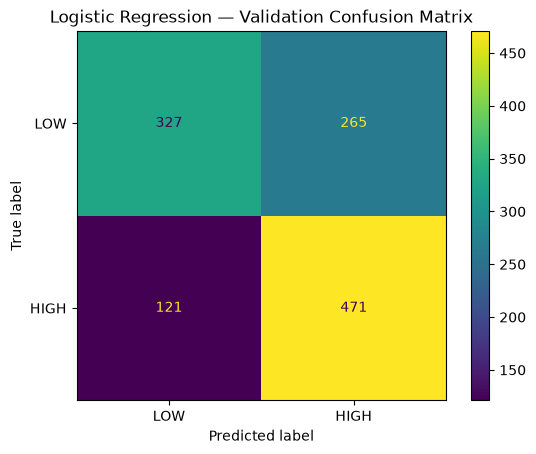

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    display_labels=["LOW", "HIGH"]
)

plt.title("Logistic Regression — Validation Confusion Matrix")
plt.show()

In [77]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["LOW", "HIGH"]
    )
)

              precision    recall  f1-score   support

         LOW       0.73      0.55      0.63       592
        HIGH       0.64      0.80      0.71       592

    accuracy                           0.67      1184
   macro avg       0.68      0.67      0.67      1184
weighted avg       0.68      0.67      0.67      1184



Proper Subject-Wise 5-Fold Cross-Validation

In [79]:
cv_folds = splits["cv"]["folds"]

print(type(cv_folds))
print(len(cv_folds))
print(cv_folds[0])

<class 'list'>
5
{'fold': 0, 'train_subjects': [1, 2, 3, 4, 6, 7, 10, 12, 14, 15, 17, 18, 19, 21, 22, 24, 29, 30, 31, 33, 34, 35, 36, 39, 40, 42, 45, 46, 47, 48], 'val_subjects': [8, 9, 11, 16, 23, 32, 37, 43]}


the 5-fold Logistic Regression CV

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

fold_results = []

for fold in cv_folds:

    fold_number = fold["fold"]

    print("=" * 50)
    print(f"Fold {fold_number}")

    # Subjects for this fold
    fold_train_subjects = fold["train_subjects"]
    fold_val_subjects = fold["val_subjects"]

    # Convert subjects → EEG window indices
    fold_train_idx = rows_of(fold_train_subjects)
    fold_val_idx = rows_of(fold_val_subjects)

    # Features
    X_fold_train = X_abs[fold_train_idx]
    X_fold_val = X_abs[fold_val_idx]

    # Labels
    y_fold_train = y[fold_train_idx]
    y_fold_val = y[fold_val_idx]

    print("Training windows:", len(fold_train_idx))
    print("Validation windows:", len(fold_val_idx))

    # Logistic Regression pipeline
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Predictions
    y_pred = model.predict(X_fold_val)
    y_prob = model.predict_proba(X_fold_val)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_fold_val, y_pred)
    balanced_acc = balanced_accuracy_score(y_fold_val, y_pred)
    f1 = f1_score(y_fold_val, y_pred)
    roc_auc = roc_auc_score(y_fold_val, y_prob)

    fold_results.append({
        "fold": fold_number,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "f1": f1,
        "roc_auc": roc_auc
    })

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score:          {f1:.4f}")
    print(f"ROC-AUC:           {roc_auc:.4f}")

Fold 0
Training windows: 4440
Validation windows: 1184
Accuracy:          0.6123
Balanced Accuracy: 0.6123
F1 Score:          0.5905
ROC-AUC:           0.6499
Fold 1
Training windows: 4440
Validation windows: 1184
Accuracy:          0.6233
Balanced Accuracy: 0.6233
F1 Score:          0.6672
ROC-AUC:           0.6664
Fold 2
Training windows: 4440
Validation windows: 1184
Accuracy:          0.8277
Balanced Accuracy: 0.8277
F1 Score:          0.8268
ROC-AUC:           0.8025
Fold 3
Training windows: 4588
Validation windows: 1036
Accuracy:          0.6824
Balanced Accuracy: 0.6824
F1 Score:          0.6809
ROC-AUC:           0.7537
Fold 4
Training windows: 4588
Validation windows: 1036
Accuracy:          0.5772
Balanced Accuracy: 0.5772
F1 Score:          0.5974
ROC-AUC:           0.5890


In [81]:
cv_results = pd.DataFrame(fold_results)

print(cv_results)

   fold  accuracy  balanced_accuracy        f1   roc_auc
0     0  0.612331           0.612331  0.590544  0.649893
1     1  0.623311           0.623311  0.667164  0.666391
2     2  0.827703           0.827703  0.826825  0.802496
3     3  0.682432           0.682432  0.680892  0.753712
4     4  0.577220           0.577220  0.597426  0.588963


In [82]:
metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "roc_auc"
]

print("\n===== 5-FOLD CV SUMMARY =====")

for metric in metrics:
    mean = cv_results[metric].mean()
    std = cv_results[metric].std()

    print(f"{metric}: {mean:.4f} ± {std:.4f}")


===== 5-FOLD CV SUMMARY =====
accuracy: 0.6646 ± 0.0987
balanced_accuracy: 0.6646 ± 0.0987
f1: 0.6726 ± 0.0952
roc_auc: 0.6923 ± 0.0852


TILL NOW
STEW EEG
   ↓
Member 1 preprocessing
   ↓
4-sec windows
   ↓
Welch PSD
   ↓
5 frequency bands
   ↓
70 features/window
   ↓
Subject-wise CV
   ↓
StandardScaler
   ↓
Logistic Regression
   ↓
LOW vs HIGH workload
   ↓
5-fold performance

                    EEG
                     ↓
               Preprocessing
                     ↓
                4-sec windows
                     ↓
                 Welch PSD
                     ↓
             Spectral Features
                     ↓
        ┌────────────┴────────────┐
        ↓                         ↓
 Absolute Power             Relative Power
        ↓                         ↓
        └────────────┬────────────┘
                     ↓
              Classical ML
                     ↓
        ┌────────────┼────────────┐
        ↓            ↓            ↓
       LR       Linear SVM     RBF SVM
                                  ↓
                           Random Forest